<a href="https://colab.research.google.com/github/FurqanAhmad019/24i-2534/blob/main/Lab03/24_2534_DS_5A_Lab03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("Sample - Superstore.csv", encoding = "latin1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:


df['month'] = pd.to_datetime(df['Order Date']).dt.month_name()
df['year'] = pd.to_datetime(df['Order Date']).dt.year

df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'month',
       'year'],
      dtype='object')

# Bar and Line Charts

# Task 1

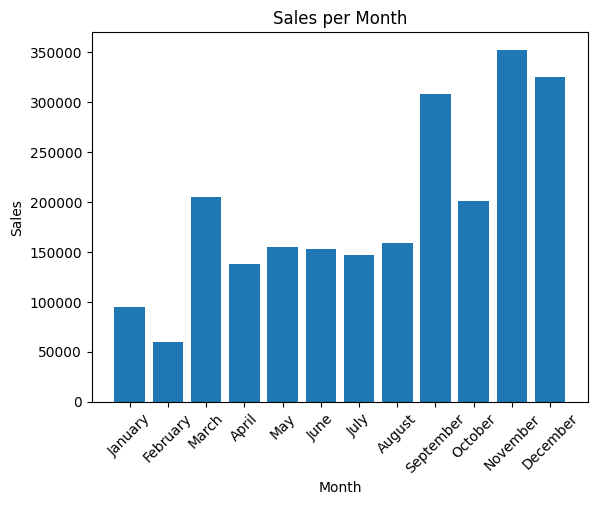

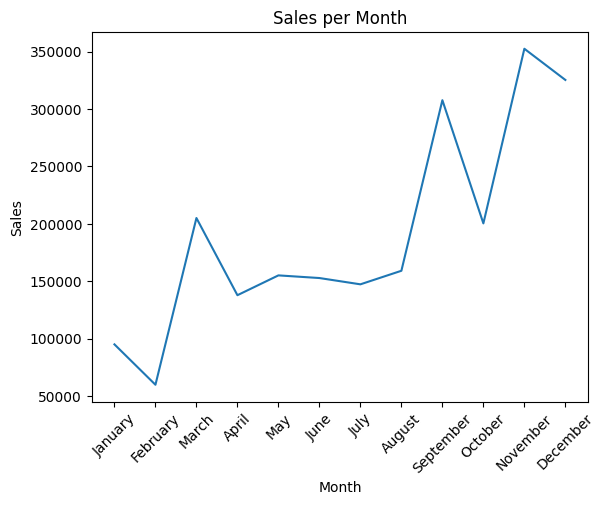

In [ ]:
monthly_sales = df.groupby('month')['Sales'].sum().reset_index()

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_sales['month'] = pd.Categorical(monthly_sales['month'], categories=month_order, ordered=True)
monthly_sales = monthly_sales.sort_values('month')

plt.bar(monthly_sales['month'], monthly_sales['Sales'])
plt.xlabel('Month')
plt.ylabel('Sales')
plt.title('Sales per Month')
plt.xticks(rotation=45)
plt.show()

plt.plot(monthly_sales['month'], monthly_sales['Sales'])
plt.xlabel('Month')
plt.ylabel('Sales')
plt.title('Sales per Month')
plt.xticks(rotation=45)
plt.show()




# Pie Chart

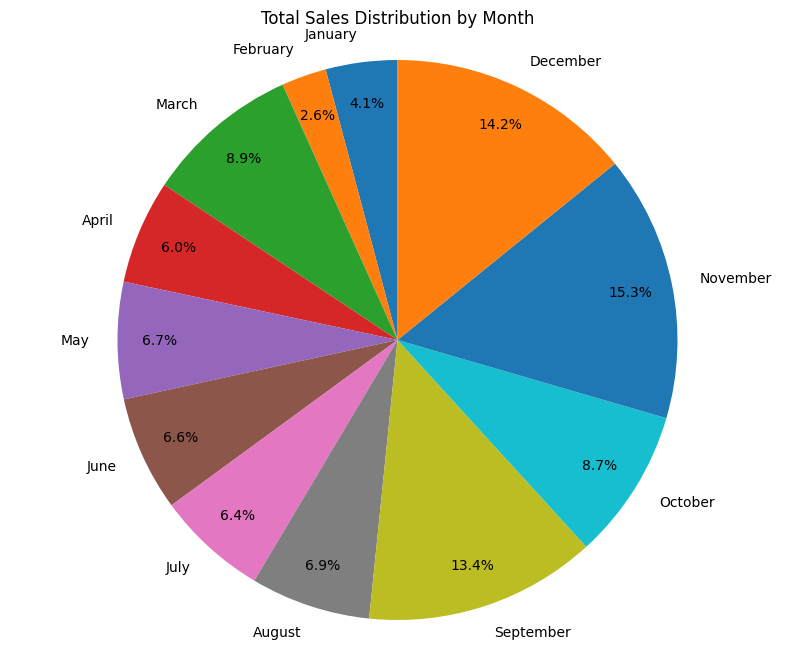

In [ ]:
plt.figure(figsize=(10, 8))
plt.pie(monthly_sales['Sales'], labels=monthly_sales['month'], autopct='%1.1f%%', startangle=90, pctdistance=0.85)
plt.title('Total Sales Distribution by Month')
plt.axis('equal')
plt.show()

# Result

Bar chart and Line Graph easily shows monthly sales throughout the year. They are great to track in which months, sales are less or more.
Pie Chart requires more memory from user to give the pattern. But Pie chart easily shows the percentages of sales for each month

# Task 2

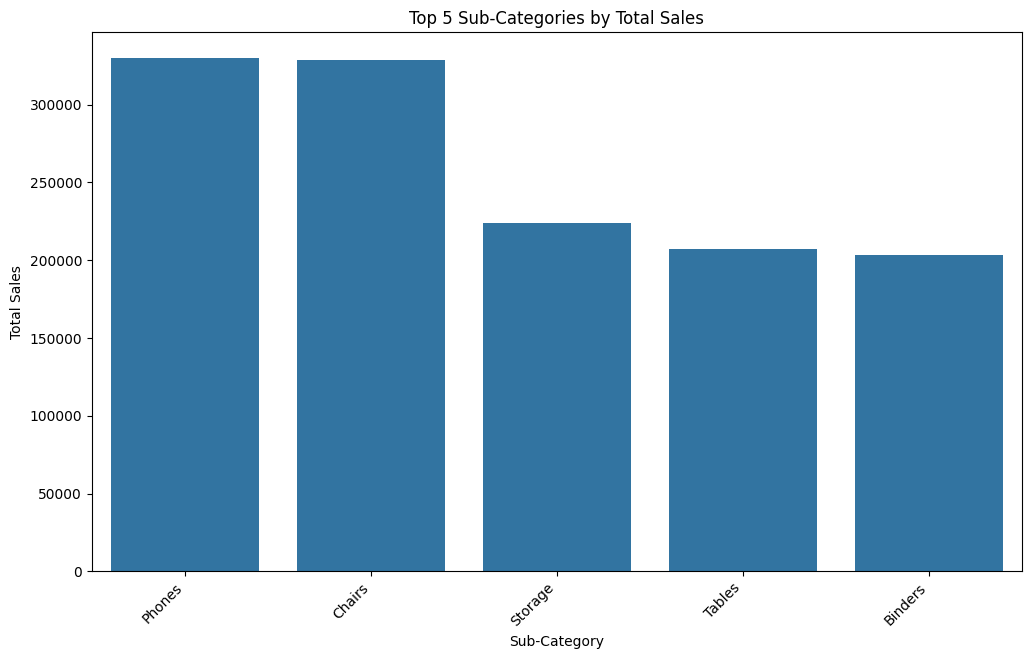

In [ ]:
sub_category_total_sales = df.groupby('Sub-Category')['Sales'].sum().reset_index()

top_5_sub_categories_df = sub_category_total_sales.sort_values(by='Sales', ascending=False).head(5)

top_5_sub_category_names = top_5_sub_categories_df['Sub-Category'].tolist()

plt.figure(figsize=(12, 7))
sns.barplot(x='Sub-Category', y='Sales', data=top_5_sub_categories_df, order=top_5_sub_category_names)
plt.xlabel('Sub-Category')
plt.ylabel('Total Sales')
plt.title('Top 5 Sub-Categories by Total Sales')
plt.xticks(rotation=45, ha='right')
plt.show()

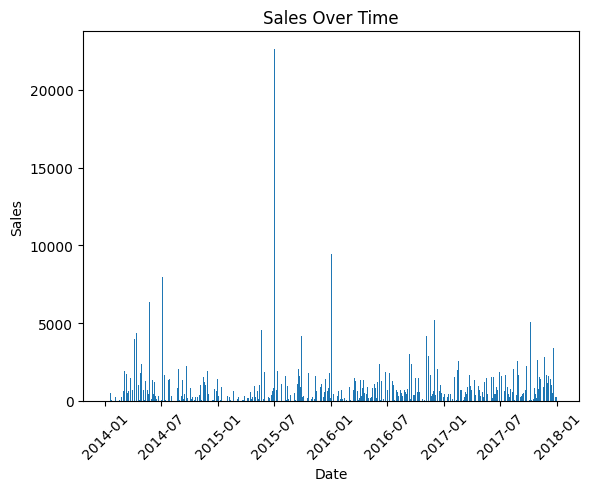

In [ ]:
Date =  pd.to_datetime(df['Order Date'])
sorted_dates = Date.sort_values(ascending=True)

plt.bar(sorted_dates, df['Sales'])
plt.xlabel('Date')
plt.ylabel('Sales')
plt.title('Sales Over Time')
plt.xticks(rotation=45)
plt.show()

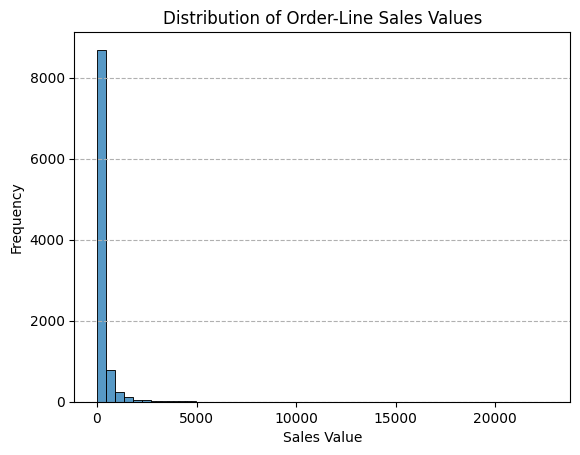

In [ ]:
sns.histplot(df['Sales'], bins=50)
plt.xlabel('Sales Value')
plt.ylabel('Frequency')
plt.title('Distribution of Order-Line Sales Values')
plt.grid(axis='y', linestyle='--')
plt.show()

Correlation between Discount and Sales: -0.21948745637176803
The relation is  negative meaning that increasing discounts decreases profit


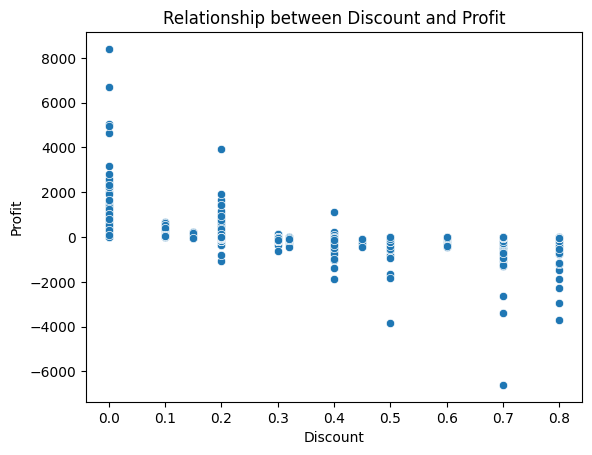

In [ ]:
corr = df['Discount'].corr(df['Profit'])
print(f"Correlation between Discount and Sales: {corr}")
print("The relation is  negative meaning that increasing discounts decreases profit")

sns.scatterplot(x='Discount', y='Profit', data=df)
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Relationship between Discount and Profit')
plt.show()

# Task 3

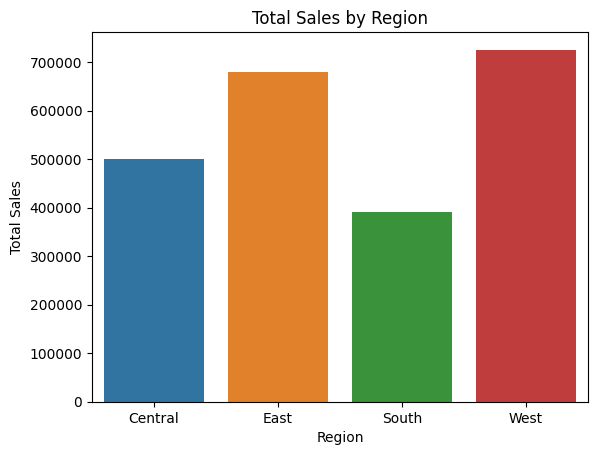

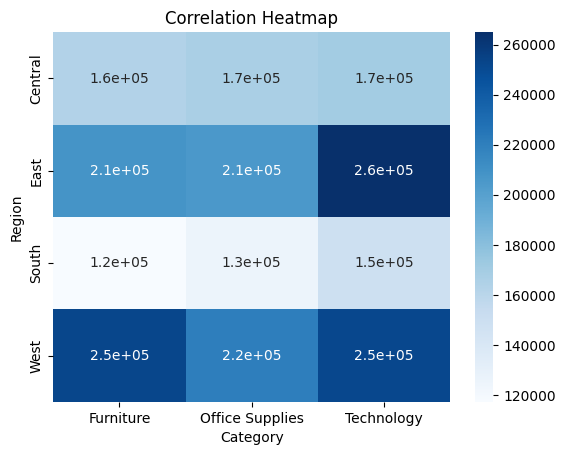

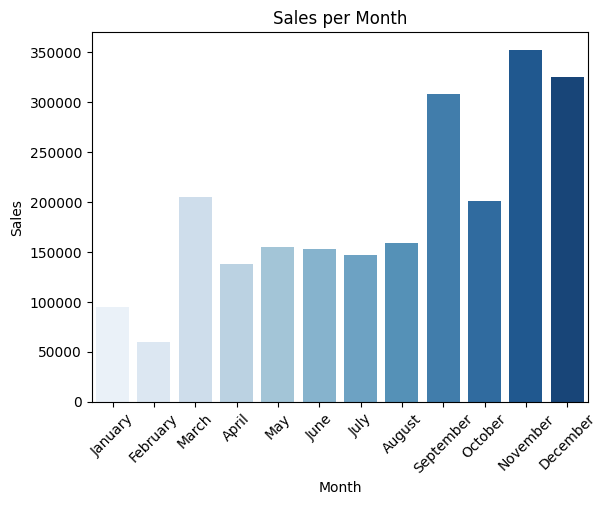

In [ ]:
sales_by_region = df.groupby('Region')['Sales'].sum().reset_index()
sales_by_region_and_category = df.groupby(['Region', 'Category'])['Sales'].sum().reset_index()
profit_by_month = df.groupby('month')['Profit'].sum().reset_index()

sns.barplot(x='Region', y='Sales', data=sales_by_region, hue = 'Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.title('Total Sales by Region')
plt.show()

heatmap_data = df.pivot_table(values='Sales', index='Region', columns='Category', aggfunc='sum')
sns.heatmap(heatmap_data, annot=True, cmap='Blues')
plt.title('Correlation Heatmap')
plt.show()

sns.barplot(data=monthly_sales, x='month', y='Sales', hue='month', palette='Blues', legend=False)
plt.xlabel('Month')
plt.ylabel('Sales')
plt.title('Sales per Month')
plt.xticks(rotation=45)
plt.show()

### Distortion Example 1: Truncated Y-axis on Region Sales

**Distortion Mechanism:** A truncated y-axis distorts the perceived difference between values by starting the axis above zero, making smaller differences appear much larger than they are.

/tmp/ipykernel_968/3372996818.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Region', y='Sales', data=sales_by_region, palette='viridis')


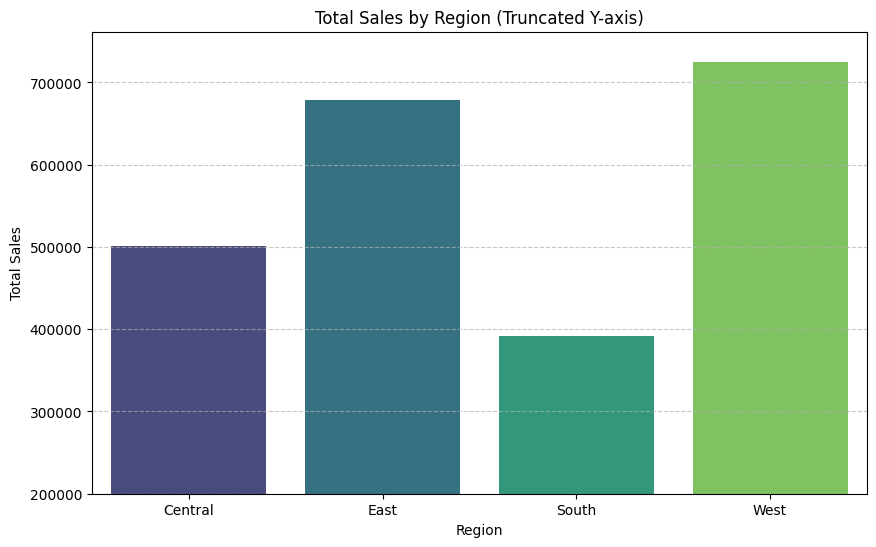

In [ ]:
# Truncated Y-axis on Region Sales Chart
plt.figure(figsize=(10, 6))
sns.barplot(x='Region', y='Sales', data=sales_by_region, palette='viridis')
plt.ylim(200000, sales_by_region['Sales'].max() * 1.05) # Truncate y-axis to exaggerate differences
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.title('Total Sales by Region (Truncated Y-axis)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Task 5

# Y-Axis traunacted:

Y-axis is trauncated and starts from 350000

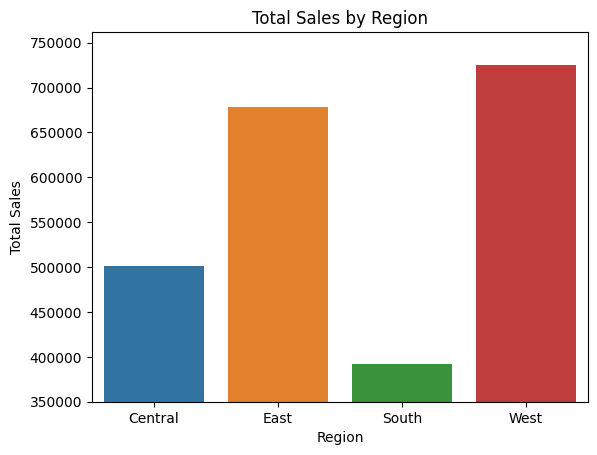

In [ ]:
sns.barplot(x='Region', y='Sales', data=sales_by_region, hue = 'Region')
plt.ylim(350000)
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.title('Total Sales by Region')
plt.show()

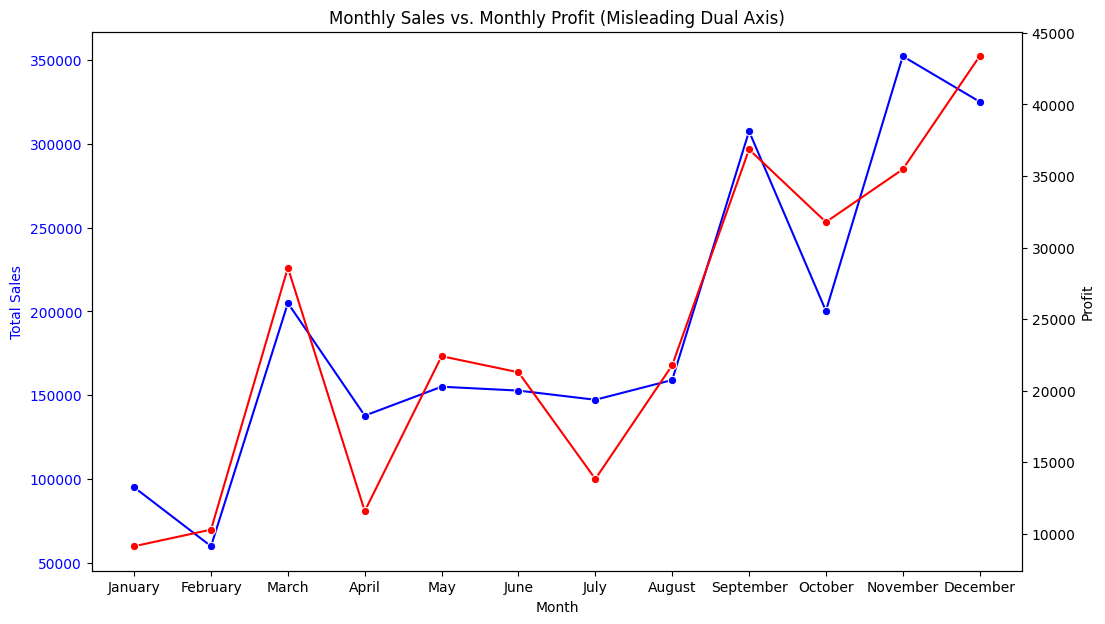

In [ ]:
monthly_data = pd.merge(monthly_sales, profit_by_month, on='month', how='left')
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_data['month'] = pd.Categorical(monthly_data['month'], categories=month_order, ordered=True)
monthly_data = monthly_data.sort_values('month')

fig, ax1 = plt.subplots(figsize=(12, 7))

sns.lineplot(x='month', y='Sales', data=monthly_data, color='blue', marker='o')
ax1.set_xlabel('Month')
ax1.set_ylabel('Total Sales', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
sns.lineplot(x='month', y='Profit', data=monthly_data, color='red', marker='o')

plt.title('Monthly Sales vs. Monthly Profit (Misleading Dual Axis)')
plt.xticks(rotation=45)
plt.show()

# Inverted Y-Axis

Y axis for profit is inverted

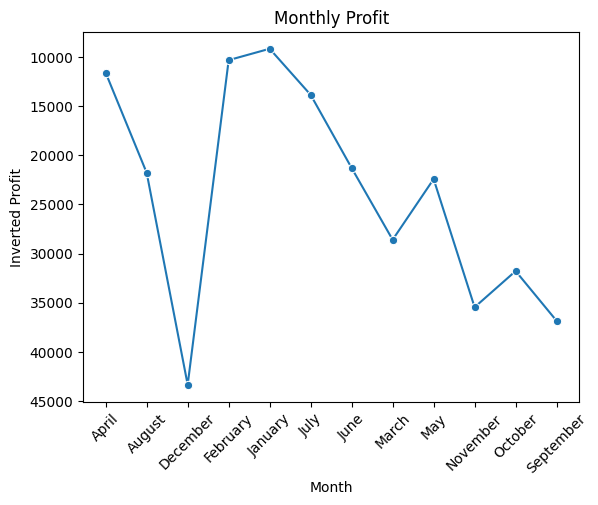

In [ ]:

sns.lineplot(x='month', y='Profit', data=profit_by_month, marker='o')
plt.gca().invert_yaxis()
plt.xlabel('Month')
plt.ylabel('Inverted Profit')
plt.title('Monthly Profit')
plt.xticks(rotation=45)
plt.show()

# Task 6

#Is discounting hurting profit?

Scatter plot can show the relationship between 2 variables and we can get patterns.

Correlation between Discount and Profit: -0.22


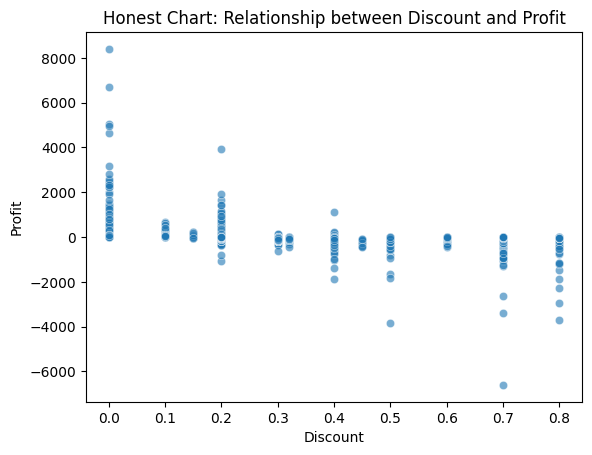

In [ ]:
corr = df['Discount'].corr(df['Profit'])
print(f"Correlation between Discount and Profit: {corr:.2f}")

sns.scatterplot(x='Discount', y='Profit', data=df, alpha=0.6)
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.title('Honest Chart: Relationship between Discount and Profit')
plt.show()


# Misleading Version

We can invert Y-axis to show opposite values

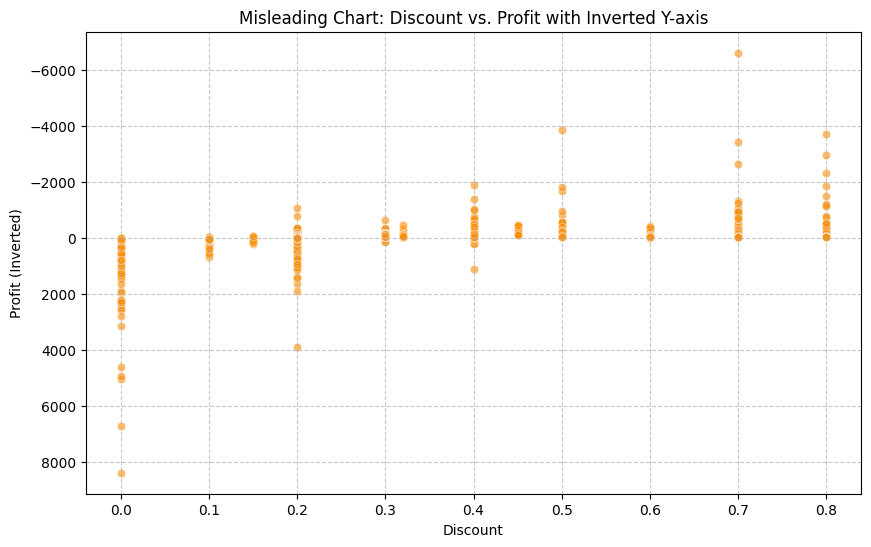

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Discount', y='Profit', data=df, alpha=0.6, color='darkorange')
plt.gca().invert_yaxis() # Invert the y-axis
plt.xlabel('Discount')
plt.ylabel('Profit (Inverted)')
plt.title('Misleading Chart: Discount vs. Profit with Inverted Y-axis')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


# Task 4(a)

In [ ]:
def get_relative_luminance(rgb):
    """Calculates the relative luminance of an RGB color tuple (0-255 scale)."""
    s_rgb = [channel / 255.0 for channel in rgb]

    linear_rgb = []
    for c in s_rgb:
        if c <= 0.03928:
            linear_rgb.append(c / 12.92)
        else:
            linear_rgb.append(((c + 0.055) / 1.055) ** 2.4)

    r, g, b = linear_rgb
    return 0.2126 * r + 0.7152 * g + 0.0722 * b


def check_wcag_contrast(color1, color2):
    """Computes the WCAG contrast ratio between two RGB colors."""
    lum1 = get_relative_luminance(color1)
    lum2 = get_relative_luminance(color2)

    l1 = max(lum1, lum2)
    l2 = min(lum1, lum2)

    ratio = (l1 + 0.05) / (l2 + 0.05)
    return round(ratio, 2)


task_3_colors = {
    "3(a) Set2 Mint Green": ((102, 194, 165), (255, 255, 255)), # #66c2a5
    "3(a) Set2 Coral/Orange": ((252, 141, 98), (255, 255, 255)), # #fc8d62
    "3(a) Set2 Slate Blue": ((141, 160, 203), (255, 255, 255)), # #8da0cb

    "3(b) Blues Light (Low Sales) vs Black Text": ((239, 243, 255), (0, 0, 0)),
    "3(b) Blues Dark (High Sales) vs White Text": ((8, 81, 156), (255, 255, 255)),
    "3(b) Blues Mid (Warning Test) vs White Text": ((107, 174, 214), (255, 255, 255)),

    "3(c) RdBu Deep Red (Loss)": ((178, 24, 43), (255, 255, 255)),   # #b2182b
    "3(c) RdBu Deep Blue (Profit)": ((33, 102, 172), (255, 255, 255)) # #2166ac
}

print(f"{'Chart Element / Color Pair':<43} | {'Ratio':<7} | {'AA Threshold (4.5:1)':<20}")
print("-" * 78)

for name, (c1, c2) in task_3_colors.items():
    ratio = check_wcag_contrast(c1, c2)

    status = "PASS" if ratio >= 4.5 else "FAIL"

    print(f"{name:<43} | {ratio:<7} | {status:<20}")


Chart Element / Color Pair                  | Ratio   | AA Threshold (4.5:1)
------------------------------------------------------------------------------
3(a) Set2 Mint Green                        | 2.14    | FAIL                
3(a) Set2 Coral/Orange                      | 2.3     | FAIL                
3(a) Set2 Slate Blue                        | 2.62    | FAIL                
3(b) Blues Light (Low Sales) vs Black Text  | 18.93   | PASS                
3(b) Blues Dark (High Sales) vs White Text  | 7.87    | PASS                
3(b) Blues Mid (Warning Test) vs White Text | 2.43    | FAIL                
3(c) RdBu Deep Red (Loss)                   | 6.87    | PASS                
3(c) RdBu Deep Blue (Profit)                | 5.9     | PASS                


# Task 4(b)

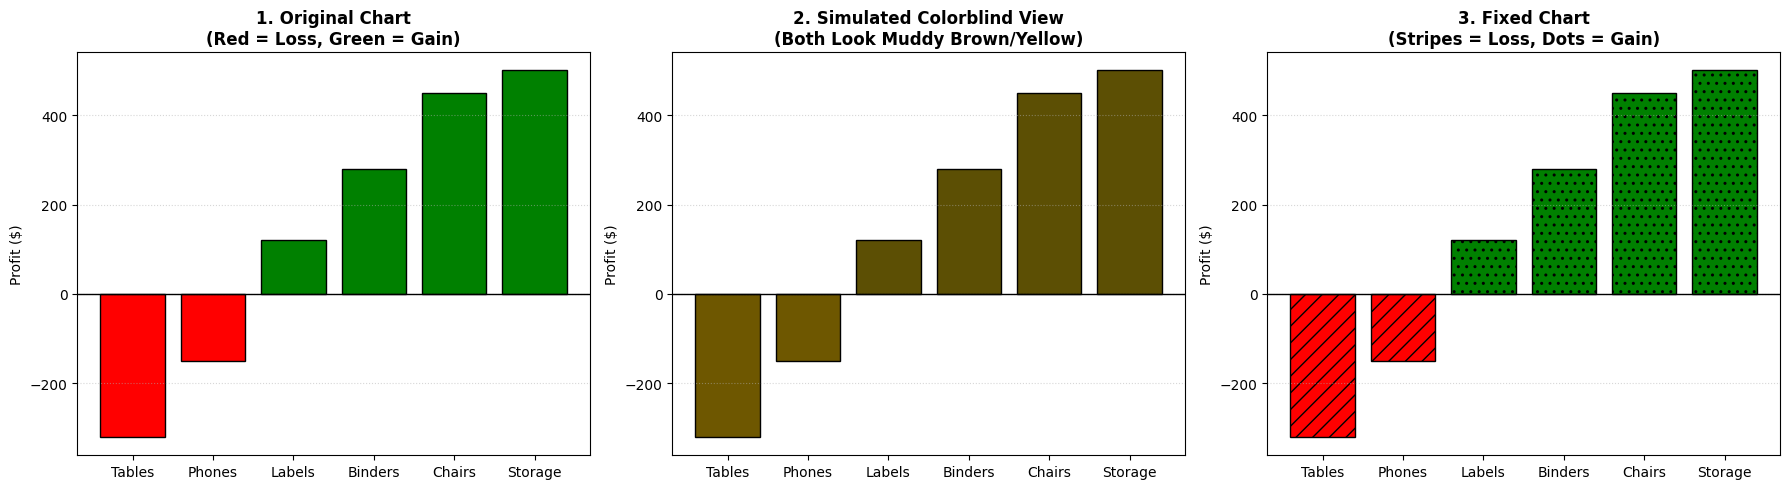

In [ ]:
data = {
    'Sub-Category': ['Chairs', 'Labels', 'Tables', 'Binders', 'Phones', 'Storage'],
    'Profit': [450, 120, -320, 280, -150, 500]
}
df = pd.DataFrame(data).sort_values('Profit').reset_index(drop=True)

colors_rgb = [np.array([1.0, 0.0, 0.0]) if x < 0 else np.array([0.0, 0.5, 0.0]) for x in df['Profit']]

def simulate_deuteranopia(rgb_list):
    """Transforms RGB color arrays using a simplified Deuteranopia simulation matrix."""
    sim_matrix = np.array([
        [0.43, 0.72, -0.15],
        [0.34, 0.62,  0.04],
        [-0.02, 0.03,  1.00]
    ])
    simulated_colors = []
    for rgb in rgb_list:
        sim_rgb = np.clip(np.dot(sim_matrix, rgb), 0, 1)
        simulated_colors.append(sim_rgb)
    return simulated_colors

colors_simulated = simulate_deuteranopia(colors_rgb)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(df['Sub-Category'], df['Profit'], color=colors_rgb, edgecolor='black')
axes[0].set_title("1. Original Chart\n(Red = Loss, Green = Gain)", fontweight='bold')

axes[1].bar(df['Sub-Category'], df['Profit'], color=colors_simulated, edgecolor='black')
axes[1].set_title("2. Simulated Colorblind View\n(Both Look Muddy Brown/Yellow)", fontweight='bold')


bars = axes[2].bar(df['Sub-Category'], df['Profit'], color=colors_rgb, edgecolor='black')
for bar, val in zip(bars, df['Profit']):
    if val < 0:
        bar.set_hatch('//')
    else:
        bar.set_hatch('..')

axes[2].set_title("3. Fixed Chart\n(Stripes = Loss, Dots = Gain)", fontweight='bold')

for ax in axes:
    ax.axhline(0, color='black', linewidth=1)
    ax.set_ylabel("Profit ($)")
    ax.grid(axis='y', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()
